# Defining Mode Sources and Monitors in BEAMZ

This notebook mirrors the Tidy3D `ModalSourcesMonitors.ipynb` example with the local `beamz-1/matplotlib` implementation. We launch the fundamental mode of a silicon waveguide, record fields on monitor planes, decompose the output into guided modes, and then repeat the calculation for a width-step junction.

The implementation is intentionally close to the original tutorial, but uses BEAMZ concepts:

- `ModeSource` computes a guided mode on the source plane and injects it into the FDTD grid.
- `Monitor` objects accumulate frequency-domain DFT fields on transverse planes.
- `PortSpec` tells BEAMZ how to project those monitor fields onto forward and backward waveguide modes.
- `Simulation.get_S_matrix_modal_dft(...)` returns modal amplitudes and normalized power spectra.

Current BEAMZ note: this branch computes each `ModeSource` spatial profile at one wavelength. Tidy3D's `ModeSource(num_freqs=...)` broadband-profile option is not currently exposed here, so this notebook uses the straight-waveguide normalization workflow for broadband correction.


## Setup

The notebook imports BEAMZ from the sibling `beamz-1` checkout when that directory is present, so it uses the local `matplotlib` branch rather than an installed package from elsewhere.


In [1]:
from pathlib import Path
import sys

for candidate in (
    Path.cwd().resolve().parent / "beamz-1",
    Path.cwd().resolve().parent.parent / "beamz-1",
):
    if (candidate / "beamz").is_dir():
        sys.path.insert(0, str(candidate))
        print(f"Using local BEAMZ checkout: {candidate}")
        break

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

from beamz import (
    LIGHT_SPEED,
    PML,
    Design,
    Material,
    ModeSource,
    Monitor,
    PortSpec,
    Rectangle,
    Simulation,
    calc_optimal_fdtd_params,
    solve_modes,
    µm,
)
from beamz.devices.sources.signals import gaussian_band_pulse

plt.rcParams.update({"figure.dpi": 120})


Using local BEAMZ checkout: /Users/quentinwach/Code/beamz-1


## Straight Waveguide Simulation

The Tidy3D example is a 3D silicon ridge waveguide on silicon dioxide. We use the same physical dimensions and place the geometry in BEAMZ's positive-coordinate design box. The FDTD mesh is deliberately coarser than the Tidy3D cloud example so it remains practical to run locally.


In [2]:
# Geometry and material parameters.
WG_HEIGHT = 0.22 * µm
WG_WIDTH = 0.45 * µm
N_SI = 3.48
N_SIO2 = 1.45
N_AIR = 1.0

# Optical band.
WL0 = 1.55 * µm
FREQ0 = LIGHT_SPEED / WL0
FWIDTH = FREQ0 / 10
NFREQS = 17
FREQS = np.linspace(FREQ0 - 2 * FWIDTH, FREQ0 + 2 * FWIDTH, NFREQS)
LAMBDAS_UM = LIGHT_SPEED / FREQS / µm
FCENT_IND = NFREQS // 2

# Simulation box and modal planes. Dimensions are in meters.
SIM_X = 5.0 * µm
SIM_Y = 4.0 * µm
SIM_Z = 2.0 * µm
SUBSTRATE_T = 1.0 * µm
WG_Z0 = SUBSTRATE_T
WG_CENTER_Z = WG_Z0 + 0.5 * WG_HEIGHT

PML_T = 0.55 * µm
SRC_X = PML_T + 0.45 * µm
SRC_MON_X = SRC_X + 0.25 * µm
OUT_X = SIM_X - PML_T - 0.45 * µm
MODE_SPAN_Y = 3.0 * µm
MODE_SPAN_Z = 1.4 * µm

# Keep this modest for local execution; increase to 10-12 for better quantitative accuracy.
POINTS_PER_WAVELENGTH = 8
POLARIZATION = "tm"
FIELD_COMPONENT = "Ez" if POLARIZATION == "tm" else "Ey"
DX, DT = calc_optimal_fdtd_params(
    WL0,
    N_SI,
    dims=3,
    safety_factor=0.9,
    points_per_wavelength=POINTS_PER_WAVELENGTH,
    width=SIM_X,
    height=SIM_Y,
    depth=SIM_Z,
)

print(f"dx = {DX/µm:.3f} um, dt = {DT*1e18:.2f} as")
print(f"grid shape approximately: {SIM_X/DX:.0f} x {SIM_Y/DX:.0f} x {SIM_Z/DX:.0f}")


dx = 0.056 um, dt = 96.50 as
grid shape approximately: 90 x 72 x 36


## Build the Structures

The straight guide is silicon on a silica substrate with air above. A second helper adds the wider output section used later for the mode-conversion junction.


In [3]:
def straight_waveguide_design():
    design = Design(
        width=SIM_X,
        height=SIM_Y,
        depth=SIM_Z,
        material=Material(N_AIR**2),
    )
    design += Rectangle(
        position=(0.0, 0.0, 0.0),
        width=SIM_X,
        height=SIM_Y,
        depth=SUBSTRATE_T,
        material=Material(N_SIO2**2),
    )
    design += Rectangle(
        position=(0.0, 0.5 * SIM_Y - 0.5 * WG_WIDTH, WG_Z0),
        width=SIM_X,
        height=WG_WIDTH,
        depth=WG_HEIGHT,
        material=Material(N_SI**2),
    )
    return design


def junction_design(wgout_width=1.4 * µm):
    design = straight_waveguide_design()
    design += Rectangle(
        position=(0.5 * SIM_X, 0.5 * SIM_Y - 0.5 * wgout_width, WG_Z0),
        width=0.5 * SIM_X,
        height=wgout_width,
        depth=WG_HEIGHT,
        material=Material(N_SI**2),
    )
    return design


design = straight_waveguide_design()
grid = design.rasterize(resolution=DX)


● Auto-selecting 3D meshing for 3D design

Output()

● 3D raster timing: setup=0.00s, structures=22.87s, pml=0.00s, total=22.87s

● 3D raster kernels: fast_enabled=False, fast_rect=0, fast_poly=0, fallback=2

● Created 3D mesh: 89 × 71 × 35 cells

● Raster cache saved: 534b2b9dc80136da040213a41d8b3c41e48b00c7e833eb581206a48e16a74bc7.npz | save=0.11s

● Rasterize wall-time: 22.87s | total=22.99s

## Source and Monitor Helpers

BEAMZ modal S-parameter extraction uses ordinary DFT monitors plus `PortSpec` metadata. For a `+x` launch, BEAMZ's current port basis reports the forward-propagating output wave on the `a_minus` branch when the output `PortSpec.direction` is `+x`; the notebook helpers below keep that convention local and label the plots in physical terms.


In [4]:
def mode_window():
    y0 = 0.5 * SIM_Y - 0.5 * MODE_SPAN_Y
    y1 = 0.5 * SIM_Y + 0.5 * MODE_SPAN_Y
    z0 = WG_CENTER_Z - 0.5 * MODE_SPAN_Z
    z1 = WG_CENTER_Z + 0.5 * MODE_SPAN_Z
    return y0, y1, max(0.0, z0), min(SIM_Z, z1)


def make_pulse():
    return gaussian_band_pulse(
        FREQS,
        carrier_frequency=FREQ0,
        dt=DT,
        run_after_sources_uoc=25.0,
        max_output_distance_um=(OUT_X - SRC_X) / µm,
    )


def make_source(grid, pulse):
    return ModeSource(
        grid=grid,
        center=(SRC_X, 0.5 * SIM_Y, WG_CENTER_Z),
        width=MODE_SPAN_Y,
        height=MODE_SPAN_Z,
        wavelength=WL0,
        pol=POLARIZATION,
        signal=pulse.signal,
        direction="+x",
    )


def dft_monitor(name, x, freqs=FREQS, record_fields=False):
    y0, y1, z0, z1 = mode_window()
    return Monitor(
        start=(x, y0, z0),
        end=(x, y1, z1),
        name=name,
        record_fields=record_fields,
        accumulate_power=False,
        dft_enabled=True,
        dft_frequencies=np.asarray(freqs, dtype=float),
        dft_components=("Ex", "Ey", "Ez", "Hx", "Hy", "Hz"),
        dft_window="none",
        dft_record_every_step=True,
    )



def build_simulation(design):
    grid = design.rasterize(resolution=DX)
    pulse = make_pulse()
    source = make_source(grid, pulse)
    monitors = [
        dft_monitor("src_ref", SRC_X),
        dft_monitor("src", SRC_MON_X),
        dft_monitor("out", OUT_X),
    ]
    sim = Simulation(
        design=design,
        sources=[source],
        monitors=monitors,
        boundaries=[PML(edges="all", thickness=PML_T, formulation="sponge")],
        time=pulse.time,
        resolution=DX,
    )
    return sim, source, monitors, pulse


def modal_ports(num_modes=3):
    ports = [
        PortSpec(
            name="src",
            monitor_name="src",
            reference_monitor="src_ref",
            direction="+x",
            polarization=POLARIZATION,
            mode_index=0,
            incident_wave="auto",
            scattered_wave="auto",
        )
    ]
    ports.extend(
        PortSpec(
            name=f"out_m{idx}",
            monitor_name="out",
            direction="+x",
            polarization=POLARIZATION,
            mode_index=idx,
            incident_wave="plus",
            scattered_wave="minus",
        )
        for idx in range(num_modes)
    )
    return ports


# Tidy3D-style plotting helpers for this example.
MAT_COLORS = mpl.colors.ListedColormap(["#f5f5f5", "#83abc0", "#d86c96"])
MAT_NORM = mpl.colors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5], MAT_COLORS.N)


def material_categories(eps):
    eps = np.real(np.asarray(eps))
    sub_mid = 0.5 * (N_AIR**2 + N_SIO2**2)
    core_mid = 0.5 * (N_SIO2**2 + N_SI**2)
    return np.where(eps >= core_mid, 2, np.where(eps >= sub_mid, 1, 0))


def add_pml_hatching(ax, *, plane):
    x0, x1 = -0.5 * SIM_X / µm, 0.5 * SIM_X / µm
    p = PML_T / µm
    hatch_style = dict(facecolor="#9a9a9a", alpha=0.35, hatch="xx", edgecolor="#777777", linewidth=0.0)
    ax.axvspan(x0, x0 + p, **hatch_style)
    ax.axvspan(x1 - p, x1, **hatch_style)
    if plane == "xy":
        y0, y1 = -0.5 * SIM_Y / µm, 0.5 * SIM_Y / µm
    else:
        y0, y1 = -WG_CENTER_Z / µm, (SIM_Z - WG_CENTER_Z) / µm
    ax.axhspan(y0, y0 + p, **hatch_style)
    ax.axhspan(y1 - p, y1, **hatch_style)


def add_modal_plane_markers(ax, *, plane, source=True):
    x_src = SRC_X / µm - 0.5 * SIM_X / µm
    x_out = OUT_X / µm - 0.5 * SIM_X / µm
    y0, y1, z0, z1 = mode_window()
    if plane == "xy":
        a0 = y0 / µm - 0.5 * SIM_Y / µm
        a1 = y1 / µm - 0.5 * SIM_Y / µm
        mid = 0.0
    else:
        a0 = z0 / µm - WG_CENTER_Z / µm
        a1 = z1 / µm - WG_CENTER_Z / µm
        mid = 0.0
    ax.plot([x_out, x_out], [a0, a1], color="#f4a51c", lw=2.0)
    if source:
        ax.annotate(
            "",
            xy=(x_src + 0.55, mid),
            xytext=(x_src, mid),
            arrowprops=dict(arrowstyle="-|>", color="#11823b", lw=2.0),
        )


def plot_simulation_cross_sections(grid, *, junction=False, source=True):
    eps = np.asarray(grid.permittivity)
    z_index = int(np.clip(round(WG_CENTER_Z / DX), 0, eps.shape[0] - 1))
    y_index = int(np.clip(round(0.5 * SIM_Y / DX), 0, eps.shape[1] - 1))
    xy = material_categories(eps[z_index, :, :])
    xz = material_categories(eps[:, y_index, :])

    if junction:
        fig = plt.figure(figsize=(11, 4))
        gs = mpl.gridspec.GridSpec(1, 2, figure=fig, width_ratios=[1, 1.4])
        axes = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])]
    else:
        fig, axes = plt.subplots(1, 2, tight_layout=True, figsize=(11, 4))

    axes[0].imshow(
        xy,
        origin="lower",
        extent=[-0.5 * SIM_X / µm, 0.5 * SIM_X / µm, -0.5 * SIM_Y / µm, 0.5 * SIM_Y / µm],
        cmap=MAT_COLORS,
        norm=MAT_NORM,
        aspect="equal",
        interpolation="nearest",
    )
    axes[0].set_title(f"cross section at z={WG_HEIGHT / 2 / µm:.2f} (um)", fontsize=9)
    axes[0].set_xlabel("x (um)")
    axes[0].set_ylabel("y (um)")
    add_pml_hatching(axes[0], plane="xy")
    add_modal_plane_markers(axes[0], plane="xy", source=source)

    axes[1].imshow(
        xz,
        origin="lower",
        extent=[-0.5 * SIM_X / µm, 0.5 * SIM_X / µm, -WG_CENTER_Z / µm, (SIM_Z - WG_CENTER_Z) / µm],
        cmap=MAT_COLORS,
        norm=MAT_NORM,
        aspect="equal",
        interpolation="nearest",
    )
    axes[1].set_title("cross section at y=0.00 (um)", fontsize=9)
    axes[1].set_xlabel("x (um)")
    axes[1].set_ylabel("z (um)")
    add_pml_hatching(axes[1], plane="xz")
    add_modal_plane_markers(axes[1], plane="xz", source=source)
    for ax in axes:
        ax.set_xlim(-0.5 * SIM_X / µm, 0.5 * SIM_X / µm)
    fig.tight_layout()
    return fig, axes


def plot_mode_field_components(grid, *, num_modes=3):
    eps = np.asarray(grid.permittivity)
    src_index = int(np.clip(round(SRC_X / DX), 0, eps.shape[2] - 1))
    eps_profile = eps[:, :, src_index]
    neffs, e_fields, h_fields, _ = solve_modes(
        eps=eps_profile,
        omega=2 * np.pi * FREQ0,
        dL=DX,
        m=num_modes,
        direction="-x",
        filter_pol=POLARIZATION,
        target_neff=0.98 * N_SI,
        return_fields=True,
    )
    fig, axes = plt.subplots(num_modes, 2, figsize=(12, 12), constrained_layout=True)
    extent = [-0.5 * SIM_Y / µm, 0.5 * SIM_Y / µm, -WG_CENTER_Z / µm, (SIM_Z - WG_CENTER_Z) / µm]
    for mode_index in range(num_modes):
        for col, (component_name, component_index) in enumerate((("Ey", 1), ("Ez", 2))):
            ax = axes[mode_index, col]
            arr = np.squeeze(np.asarray(e_fields[mode_index, component_index]))
            im = ax.imshow(
                np.abs(arr),
                origin="lower",
                extent=extent,
                cmap="magma",
                aspect="equal",
                interpolation="nearest",
            )
            ax.set_title(f"{component_name}, mode_index={mode_index}", fontsize=9)
            ax.set_xlabel("y (um)")
            ax.set_ylabel("z (um)")
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    return fig, axes, neffs


## Visualize the Setup and Source Mode

The first plot shows the simulation layout. Then we initialize the `ModeSource` explicitly and plot the modal field components used by this branch. For this asymmetric ridge in the current BEAMZ branch, `pol="tm"` selects the confined silicon guided mode; `pol="te"` tends to select a substrate-like branch.


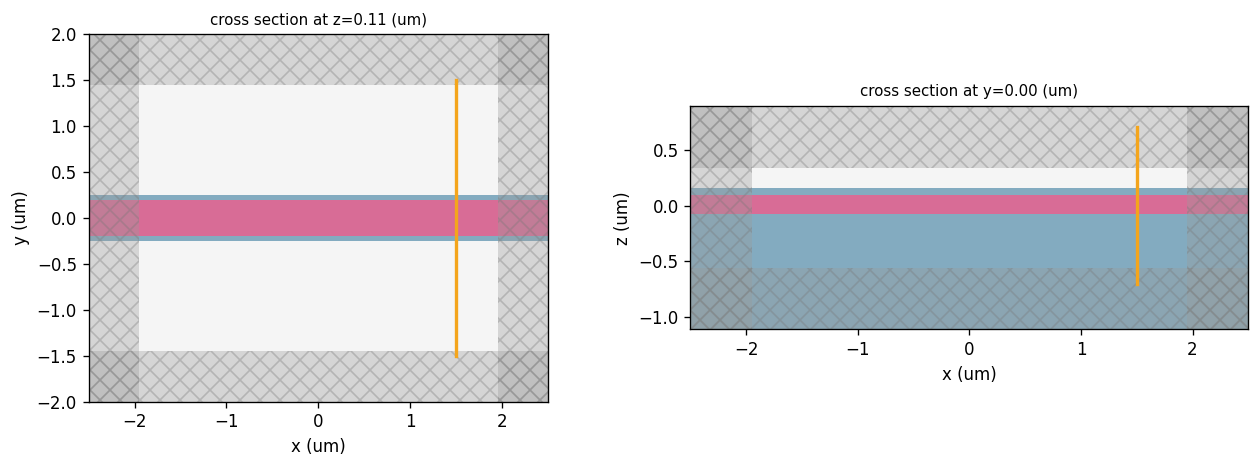

Selected source effective index: 2.1878
Mode effective indices: [2.18784954 1.29236121 1.28992169]


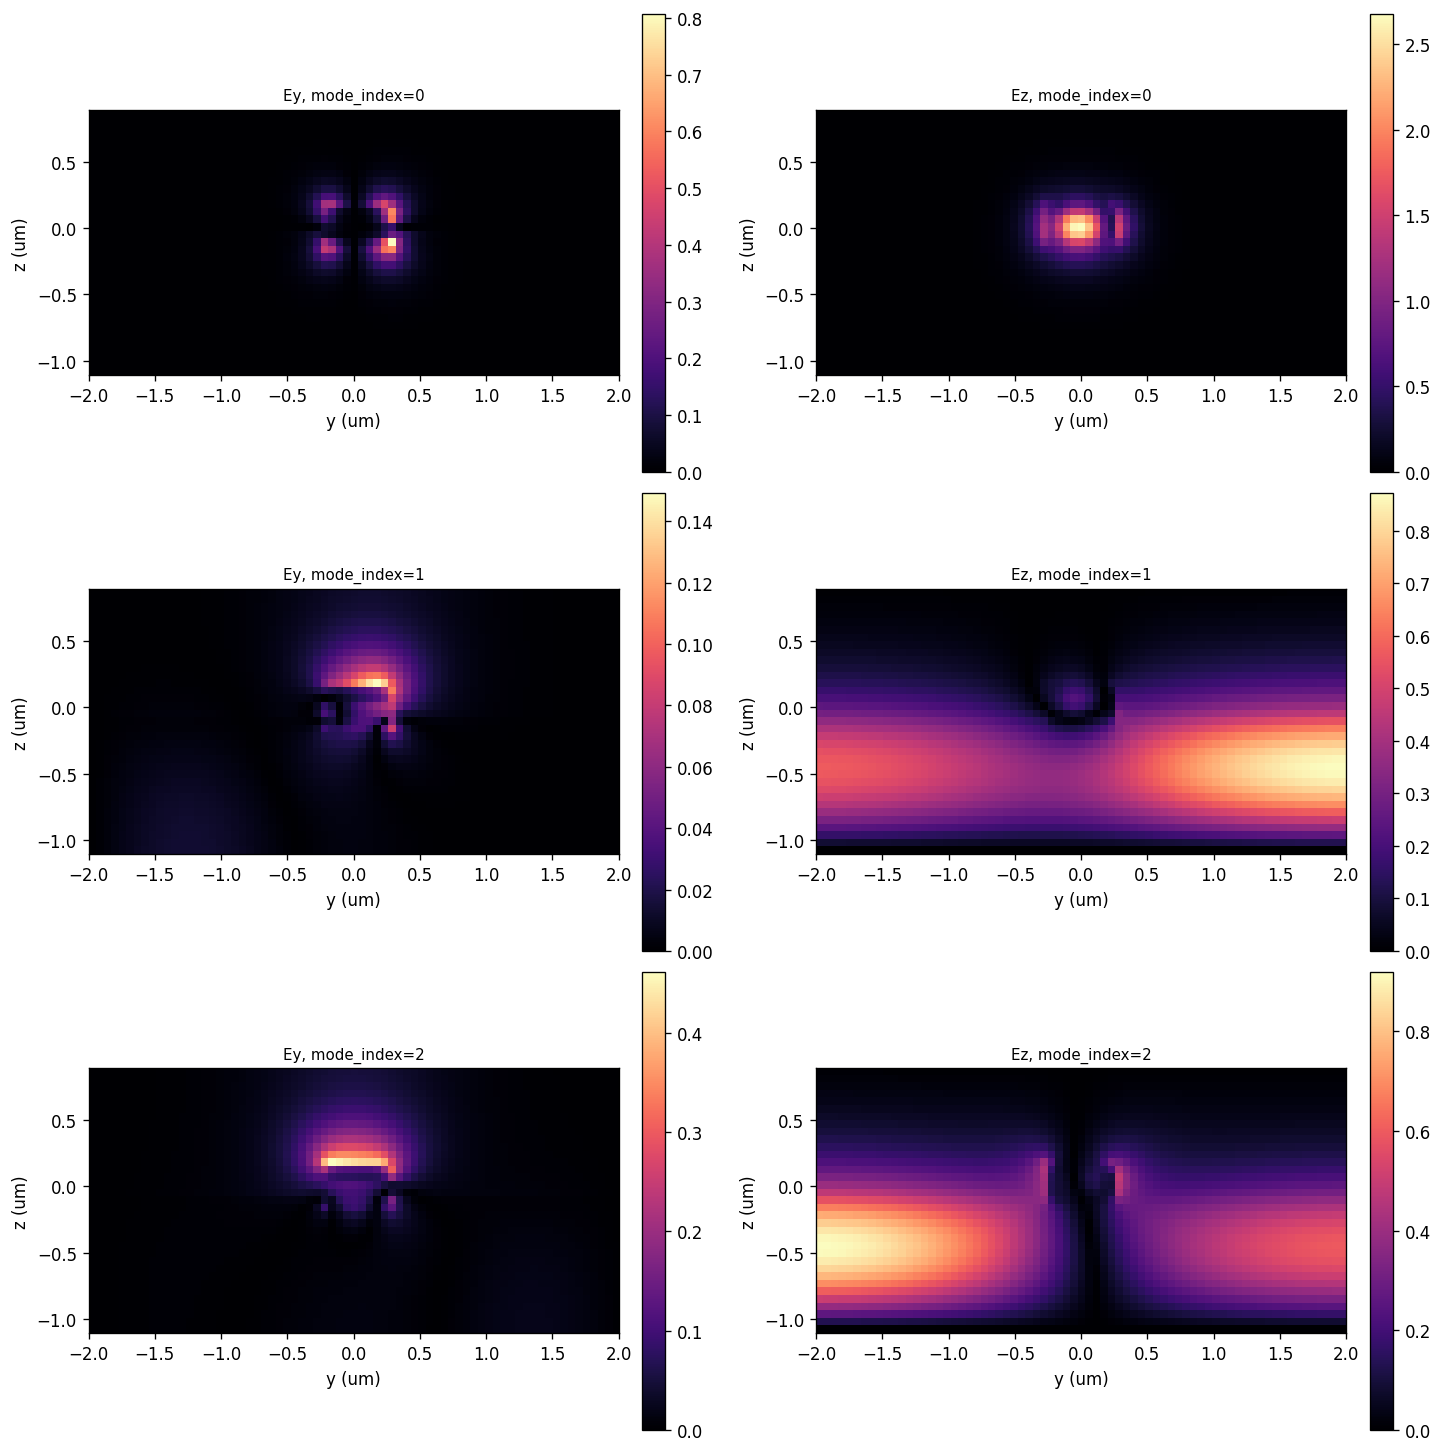

In [5]:
sim_preview, source_preview, monitors_preview, pulse_preview = build_simulation(design)
fig, axes = plot_simulation_cross_sections(grid, source=False)
plt.show()

source_preview.initialize(grid.permittivity, DX, dt=DT)
print(f"Selected source effective index: {np.real(source_preview._neff):.4f}")

fig, axes, source_neffs = plot_mode_field_components(grid, num_modes=3)
print("Mode effective indices:", np.real(source_neffs))
plt.show()


## Run the Straight Waveguide

The run accumulates DFT fields on the source/reference and output planes. The modal projection then gives normalized mode powers. We also save one final full-field snapshot for the in-plane field plot, avoiding BEAMZ's current compiled 3D monitor-power path.


In [6]:
RUN_SIMULATIONS = True

straight_result = None
if RUN_SIMULATIONS:
    sim_straight, source_straight, monitors_straight, pulse_straight = build_simulation(straight_waveguide_design())
    straight_run = sim_straight.run_compiled(
        progress=True,
        record_interval=sim_straight.num_steps,
        record_fields=[FIELD_COMPONENT],
    )
    print(f"completed {sim_straight.current_step} FDTD steps")

    straight_result = sim_straight.get_S_matrix_modal_dft(
        source_port="src",
        ports=modal_ports(num_modes=3),
        output_ports=["src", "out_m0", "out_m1", "out_m2"],
        frequencies=FREQS,
        as_sax=False,
        return_diagnostics=True,
        min_incident_db=-50.0,
    )
else:
    print("Set RUN_SIMULATIONS = True to run the local FDTD solve.")


● Raster cache hit (3d): 534b2b9dc80136da040213a41d8b3c41e48b00c7e833eb581206a48e16a74bc7.npz | load=0.02s

● JIT compiling v0.3 packed FDTD program... done!
● Progress: 100% (13127/13127 steps)
completed 13127 FDTD steps


## In-Plane Fields

The original Tidy3D notebook plots the frequency-domain `Ey` field. Here we plot the final recorded time-domain field component associated with the selected BEAMZ polarization (`Ez` for `tm`) on the horizontal plane through the waveguide center, which is useful for quickly checking directionality and confinement.


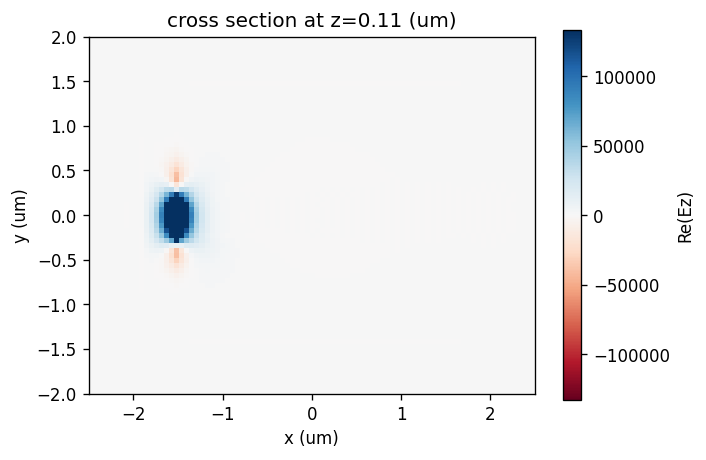

In [7]:
if RUN_SIMULATIONS:
    field_history = straight_run.fields.get(FIELD_COMPONENT) if straight_run and straight_run.fields else None
    if field_history is not None and len(field_history):
        field_last = np.asarray(field_history[-1])
        if field_last.ndim == 3:
            z_index = int(np.clip(round(WG_CENTER_Z / DX), 0, field_last.shape[0] - 1))
            field_last = field_last[z_index]
        vmax = np.nanpercentile(np.abs(np.real(field_last)), 99.5)
        vmax = vmax if np.isfinite(vmax) and vmax > 0 else 1.0
        plt.figure(figsize=(6, 4))
        plt.imshow(
            np.real(field_last),
            origin="lower",
            extent=[-0.5 * SIM_X / µm, 0.5 * SIM_X / µm, -0.5 * SIM_Y / µm, 0.5 * SIM_Y / µm],
            cmap="RdBu",
            vmin=-vmax,
            vmax=vmax,
            aspect="equal",
        )
        plt.colorbar(label=f"Re({FIELD_COMPONENT})")
        plt.xlabel("x (um)")
        plt.ylabel("y (um)")
        plt.title(f"cross section at z={WG_HEIGHT / 2 / µm:.2f} (um)")
        plt.show()
    else:
        print(f"No {FIELD_COMPONENT} field snapshot was recorded.")


## Mode Monitor Decomposition

For the output monitor, BEAMZ solves local waveguide modes on the monitor cross-section and computes complex amplitudes for both propagation branches. The modal power in each branch is $|a|^2$ after normalization by the source port incident amplitude.


Flux at central frequency: 0.0010301677403949027
Power distribution at central frequency in first three modes
  positive dir.  [0.54727939 0.001709   0.02854502]
  negative dir.  [1.06182271e-02 4.45180412e-05 1.53243563e-03]


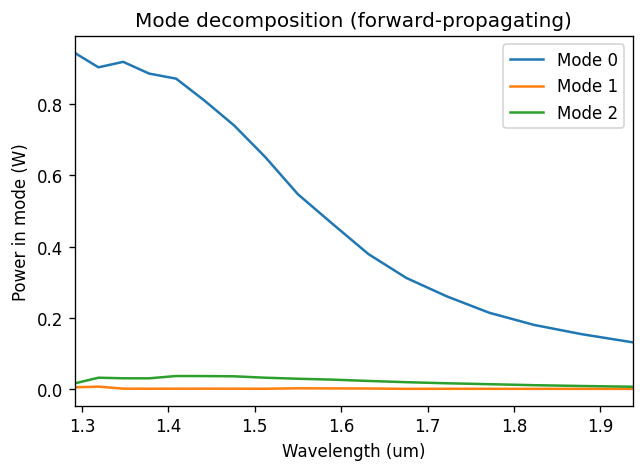

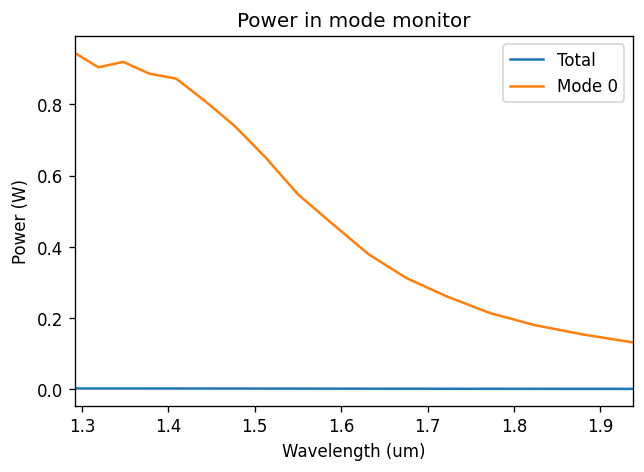

In [8]:
if RUN_SIMULATIONS:
    s_straight = straight_result["s_matrix"]
    diag_straight = straight_result["diagnostics"]
    flux_straight = np.asarray(next(m for m in monitors_straight if m.name == "out").get_dft_flux(), dtype=float)
    pin_straight = np.asarray(diag_straight["P_in"], dtype=float)
    flux_straight_norm = flux_straight / np.maximum(pin_straight, 1e-18)

    forward_power = np.vstack([np.abs(s_straight[(f"out_m{i}", "src")]) ** 2 for i in range(3)]).T
    waves = diag_straight["waves"]
    src_incident = np.sqrt(np.maximum(pin_straight, 1e-18))
    backward_raw = np.vstack([np.abs(waves[f"out_m{i}"]["a_plus"] / src_incident) ** 2 for i in range(3)]).T

    print("Flux at central frequency:", flux_straight_norm[FCENT_IND])
    print("Power distribution at central frequency in first three modes")
    print("  positive dir. ", forward_power[FCENT_IND])
    print("  negative dir. ", backward_raw[FCENT_IND])

    fig, ax = plt.subplots(1, figsize=(6, 4))
    for idx in range(3):
        ax.plot(LAMBDAS_UM, forward_power[:, idx], label=f"Mode {idx}")
    ax.set_xlim([LAMBDAS_UM[-1], LAMBDAS_UM[0]])
    ax.set_xlabel("Wavelength (um)")
    ax.set_ylabel("Power in mode (W)")
    ax.set_title("Mode decomposition (forward-propagating)")
    ax.legend()
    plt.show()

    fig, ax = plt.subplots(1, figsize=(6, 4))
    ax.plot(LAMBDAS_UM, flux_straight_norm, label="Total")
    ax.plot(LAMBDAS_UM, forward_power[:, 0], label="Mode 0")
    ax.set_xlim([LAMBDAS_UM[-1], LAMBDAS_UM[0]])
    ax.set_xlabel("Wavelength (um)")
    ax.set_ylabel("Power (W)")
    ax.set_title("Power in mode monitor")
    ax.legend()
    plt.show()


## Waveguide Junction with Straight-Guide Normalization

Next we reproduce the Tidy3D width-step example by adding a wider silicon guide in the second half of the domain. The output guide is multimode, so the modal monitor quantifies how much power remains in the fundamental mode and how much transfers to higher-order modes.


● Auto-selecting 3D meshing for 3D design

Output()

● 3D raster timing: setup=0.00s, structures=25.30s, pml=0.00s, total=25.30s

● 3D raster kernels: fast_enabled=False, fast_rect=0, fast_poly=0, fallback=3

● Created 3D mesh: 89 × 71 × 35 cells

● Raster cache saved: 95d7b35ffa7586b3fbb74a437391f38ae10c4afb6c4515eeec020f6d56a8202c.npz | save=0.10s

● Rasterize wall-time: 25.31s | total=25.41s

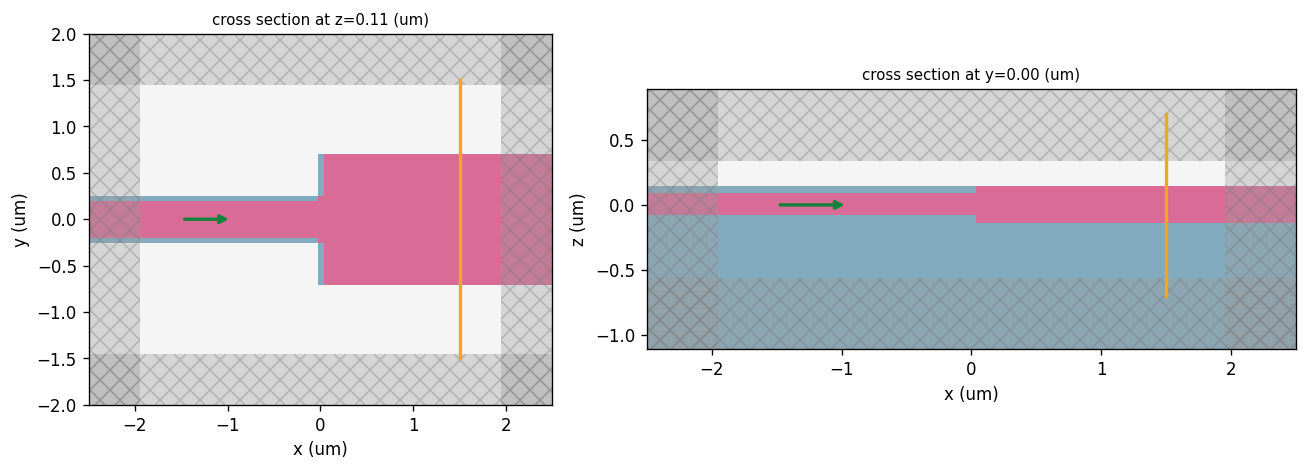

In [9]:
design_junction = junction_design(wgout_width=1.4 * µm)
grid_junction = design_junction.rasterize(resolution=DX)
fig, axes = plot_simulation_cross_sections(grid_junction, junction=True, source=True)
plt.show()


In [10]:
junction_result = None
if RUN_SIMULATIONS:
    sim_jct, source_jct, monitors_jct, pulse_jct = build_simulation(design_junction)
    junction_run = sim_jct.run_compiled(
        progress=True,
        record_interval=sim_jct.num_steps,
        record_fields=[FIELD_COMPONENT],
    )
    print(f"completed {sim_jct.current_step} FDTD steps")

    junction_result = sim_jct.get_S_matrix_modal_dft(
        source_port="src",
        ports=modal_ports(num_modes=3),
        output_ports=["src", "out_m0", "out_m1", "out_m2"],
        frequencies=FREQS,
        as_sax=False,
        return_diagnostics=True,
        min_incident_db=-50.0,
    )


● JIT compiling v0.3 packed FDTD program... done!
● Progress: 100% (13127/13127 steps)
completed 13127 FDTD steps


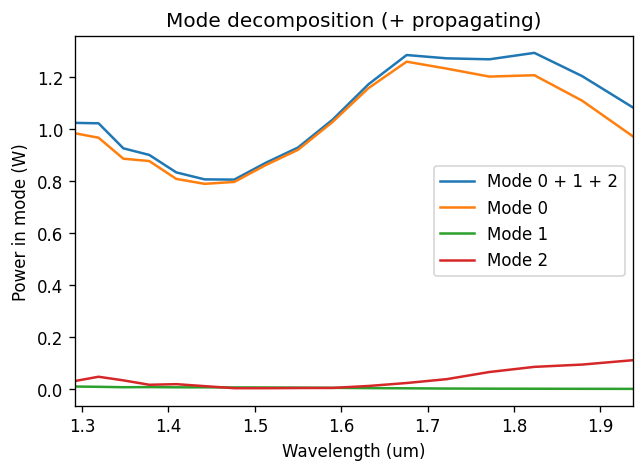

In [11]:
if RUN_SIMULATIONS:
    s_jct = junction_result["s_matrix"]
    jct_forward_power = np.vstack([np.abs(s_jct[(f"out_m{i}", "src")]) ** 2 for i in range(3)]).T

    # Straight-guide normalization compensates the frequency dependence of the local source launch.
    norm = np.maximum(forward_power[:, 0], 1e-18)
    jct_forward_power_norm = jct_forward_power / norm[:, None]

    fig, ax = plt.subplots(1, figsize=(6, 4))
    ax.plot(LAMBDAS_UM, np.sum(jct_forward_power_norm, axis=1), label="Mode 0 + 1 + 2")
    for idx in range(3):
        ax.plot(LAMBDAS_UM, jct_forward_power_norm[:, idx], label=f"Mode {idx}")
    ax.set_xlabel("Wavelength (um)")
    ax.set_xlim([LAMBDAS_UM[-1], LAMBDAS_UM[0]])
    ax.set_ylabel("Power in mode (W)")
    ax.set_title("Mode decomposition (+ propagating)")
    ax.legend()
    plt.show()


## Broadband Source Comparison in This BEAMZ Branch

The original Tidy3D tutorial finishes by comparing a single-frequency mode source with `ModeSource(num_freqs=7)`, where the injected modal profile is approximated across the source bandwidth.

In the local `beamz-1/matplotlib` implementation used here, `ModeSource` accepts one `wavelength` and does not expose a `num_freqs` broadband modal-profile argument. The practical BEAMZ workflow today is therefore the normalization-run approach above: run a straight guide once, use its measured modal launch spectrum as the reference, and normalize the device result by that spectrum.


In [12]:
print("BEAMZ ModeSource currently uses one modal profile wavelength:", WL0 / µm, "um")
print("Use the straight-guide normalization spectrum `forward_power[:, 0]` when comparing broadband device runs.")


BEAMZ ModeSource currently uses one modal profile wavelength: 1.55 um
Use the straight-guide normalization spectrum `forward_power[:, 0]` when comparing broadband device runs.


## Summary

This notebook reproduces the core of the Tidy3D mode-source and mode-monitor example in BEAMZ:

1. Build a 3D silicon-on-silica straight waveguide.
2. Launch the fundamental guided mode with `ModeSource`.
3. Accumulate DFT fields on monitor planes.
4. Project those fields onto local waveguide modes with `PortSpec` and `get_S_matrix_modal_dft`.
5. Use a straight-waveguide normalization run to analyze mode conversion in a wider output waveguide.
